In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, gaussian_kde, norm
from math import pi

In [3]:
# --- Reproducibility ---
np.random.seed(0)

# ===============================================================
# BOOTSTRAP_LOGISTIC_MEAN_AND_CI
# ===============================================================
mu, s, n = 0, 1, 80
u = np.random.rand(n)
X = mu + s * np.log(u / (1 - u))

xbar = np.mean(X)
s_hat = np.sqrt(np.var(X, ddof=1) * 3 / np.pi**2)
z = 1.96
ci_norm = [
    xbar - z * np.sqrt((np.pi**2 * s_hat**2) / (3 * n)),
    xbar + z * np.sqrt((np.pi**2 * s_hat**2) / (3 * n))
]

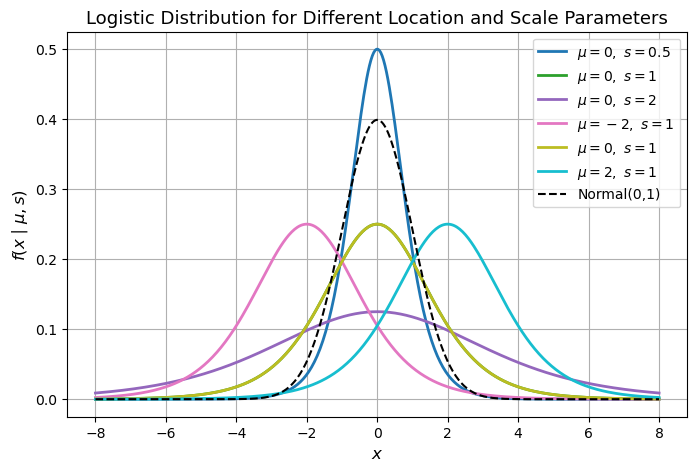

In [7]:
# --------------------------------------------------------------
# Q1(a) Visualization of the Logistic Distribution
# --------------------------------------------------------------

# Logistic PDF definition
def logistic_pdf(x, mu, s):
    z = (x - mu) / s
    return np.exp(-z) / (s * (1 + np.exp(-z))**2)

# x-grid for plotting
x = np.linspace(-8, 8, 400)

# Parameter sets
mu_vals = [0, 0, 0, -2, 0, 2]      # vary both location and scale
s_vals  = [0.5, 1, 2, 1, 1, 1]     # first 3 vary scale, last 3 vary location
colors = plt.cm.tab10(np.linspace(0, 1, len(mu_vals)))

# Plot setup
plt.figure(figsize=(8, 5), facecolor='w')
plt.grid(True)

# Plot the logistic PDFs
for i, (mu, s) in enumerate(zip(mu_vals, s_vals)):
    fx = logistic_pdf(x, mu, s)
    plt.plot(
        x, fx, linewidth=2, color=colors[i],
        label=fr'$\mu={mu},\ s={s}$'
    )

# Overlay standard normal for comparison
fx_norm = norm.pdf(x, 0, 1)
plt.plot(x, fx_norm, 'k--', linewidth=1.5, label='Normal(0,1)')

# Labels and legend
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel(r'$f(x \mid \mu, s)$', fontsize=12)
plt.title('Logistic Distribution for Different Location and Scale Parameters', fontsize=13)
plt.legend(loc='upper right', fontsize=10)
plt.show()


As shown in the graph above, changing the S parameter changes the width, and the mu parameter changes where the density function is centred. 

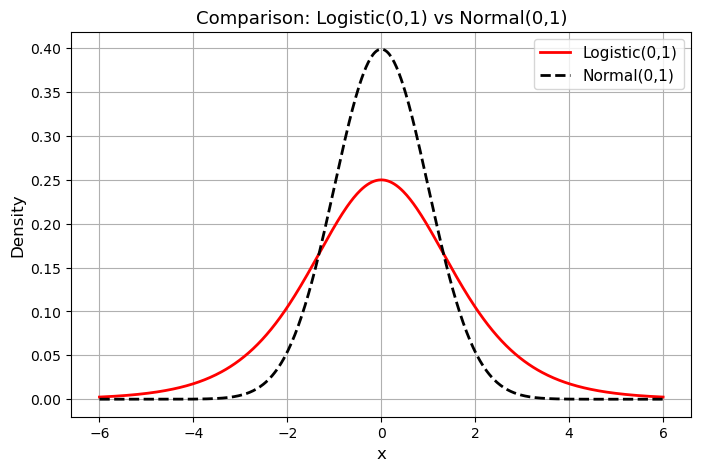

In [9]:
#Q1 C: Overlay log normal with a normal dist mu 0 var 1
x = np.linspace(-6, 6, 500)

# Logistic(0,1) and Normal(0,1)
mu, s = 0, 1
fx_logistic = logistic_pdf(x, mu, s)
fx_normal = norm.pdf(x, 0, 1)

# Plot
plt.figure(figsize=(8, 5), facecolor='w')
plt.plot(x, fx_logistic, 'r-', lw=2, label=r'Logistic(0,1)')
plt.plot(x, fx_normal, 'k--', lw=2, label=r'Normal(0,1)')
plt.title('Comparison: Logistic(0,1) vs Normal(0,1)', fontsize=13)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

In [11]:
#Q2
#from scipy.stats import norm

# -------------------------
# Utility: simulate logistic
# -------------------------
def rlogistic(n, mu=0.0, s=1.0, seed=None):
    if seed is not None:
        np.random.seed(seed)
    u = np.random.rand(n)
    return mu + s * np.log(u / (1 - u))

# -------------------------
# Score vector (for data X)
# -------------------------
def score_mu_s(mu, s, X):
    """
    Compute score vector [dℓ/dµ, dℓ/ds] for logistic log-likelihood.
    X: 1d array of observations
    mu, s: scalar
    Returns: (score_mu, score_s)
    """
    z = (X - mu) / s                # shape (n,)
    # For numerical stability compute functions using stable forms
    exp_minus_z = np.exp(-z)       # e^{-z}
    one_plus_exp_minus_z = 1.0 + exp_minus_z

    # score wrt mu: (1/s) sum tanh(z/2)
    # tanh(z/2) = (1 - e^{-z})/(1 + e^{-z})
    tanh_half = (1.0 - exp_minus_z) / one_plus_exp_minus_z
    score_mu = (1.0 / s) * np.sum(tanh_half)

    # score wrt s:
    # ∂ℓ/∂s = -n/s + (1/s^2) * sum(xi - mu) - (2/s^2) * sum( (xi-mu) * e^{-z} / (1+e^{-z}) )
    n = X.size
    sum_x_minus_mu = np.sum(X - mu)
    weighted = np.sum((X - mu) * (exp_minus_z / one_plus_exp_minus_z))
    score_s = -n / s + (1.0 / s**2) * sum_x_minus_mu - (2.0 / s**2) * weighted

    return np.array([score_mu, score_s])

# -------------------------
# Expected Fisher information (per observation)
# -------------------------
def fisher_info_per_obs(mu, s):
    """
    Returns 2x2 Fisher information matrix per observation:
    I(µ,s) = [[1/(3 s^2), 0],
              [0, (pi^2/3 - 1)/s^2 ]]
    """
    i11 = 1.0 / (3.0 * s**2)
    i22 = (pi**2 / 3.0 - 1.0) / (s**2)
    return np.array([[i11, 0.0], [0.0, i22]])

# -------------------------
# Fisher scoring algorithm
# -------------------------
def fisher_scoring(X, mu0=None, s0=None, tol=1e-8, max_iter=200, verbose=True):
    """
    Fisher scoring using expected Fisher information.
    X: data (1D array)
    mu0, s0: optional initial guesses; if None, use method-of-moments style guesses
    Returns: dict with keys 'mu_hat', 's_hat', 'iters', 'converged', 'history'
    """
    n = X.size
    # initial guesses
    if mu0 is None:
        mu0 = np.median(X)
    if s0 is None:
        # sample sd -> estimate s via s = sd * sqrt(3) / pi
        sd = np.std(X, ddof=1)
        s0 = max(1e-6, sd * np.sqrt(3) / pi)

    theta = np.array([mu0, s0], dtype=float)
    history = [theta.copy()]
    if verbose:
        print(f"Initial: mu={theta[0]:.6f}, s={theta[1]:.6f}")

    for it in range(1, max_iter + 1):
        mu, s = theta
        S = score_mu_s(mu, s, X)               # score vector (length 2)
        Iper = fisher_info_per_obs(mu, s)      # per observation
        I = n * Iper                           # expected information for full sample
        # Regularize in case s becomes tiny
        # Solve I * delta = S  => delta = inv(I) @ S  (Fisher scoring step)
        try:
            delta = np.linalg.solve(I, S)
        except np.linalg.LinAlgError:
            # fallback: pseudo-inverse
            delta = np.linalg.pinv(I) @ S

        theta_new = theta + delta
        # Keep s positive
        theta_new[1] = max(theta_new[1], 1e-8)

        history.append(theta_new.copy())

        # convergence check (relative change)
        rel_change = np.linalg.norm(delta) / (np.linalg.norm(theta) + 1e-12)
        if verbose:
            print(f"Iter {it:3d}: mu={theta_new[0]:.8f}, s={theta_new[1]:.8f}, ||delta||={np.linalg.norm(delta):.3e}, rel={rel_change:.3e}")

        theta = theta_new
        if rel_change < tol:
            if verbose:
                print(f"Converged in {it} iterations.")
            return {
                'mu_hat': float(theta[0]),
                's_hat': float(theta[1]),
                'iters': it,
                'converged': True,
                'history': np.array(history)
            }

    if verbose:
        print("Warning: Fisher scoring did NOT converge within max_iter.")
    return {
        'mu_hat': float(theta[0]),
        's_hat': float(theta[1]),
        'iters': max_iter,
        'converged': False,
        'history': np.array(history)
    }

# -------------------------
# Wald intervals
# -------------------------
def wald_intervals(mu_hat, s_hat, n, alpha=0.05):
    z = norm.ppf(1 - alpha / 2)
    se_mu = np.sqrt(3.0 * s_hat**2 / n)                       # sqrt(Var(mu_hat))
    se_s = s_hat * np.sqrt(1.0 / (n * (pi**2 / 3.0 - 1.0)))    # sqrt(Var(s_hat))
    ci_mu = (mu_hat - z * se_mu, mu_hat + z * se_mu)
    ci_s = (s_hat - z * se_s, s_hat + z * se_s)
    return {'ci_mu': ci_mu, 'ci_s': ci_s, 'se_mu': se_mu, 'se_s': se_s, 'z': z}

# -------------------------
# Example run for (b)
# -------------------------
if __name__ == "__main__":
    # generate data
    n = 200
    true_mu = 0.5
    true_s = 1.2
    X = rlogistic(n, mu=true_mu, s=true_s, seed=12345)

    # run fisher scoring
    result = fisher_scoring(X, mu0=None, s0=None, tol=1e-10, max_iter=200, verbose=True)
    mu_hat = result['mu_hat']
    s_hat = result['s_hat']

    print("\nFinal estimates:")
    print(f"  mu_hat = {mu_hat:.6f}")
    print(f"  s_hat  = {s_hat:.6f}")
    print(f"  iterations = {result['iters']}, converged = {result['converged']}")

    # Wald intervals
    w = wald_intervals(mu_hat, s_hat, n, alpha=0.05)
    print("\nLarge-sample (Wald) 95% CIs:")
    print(f"  mu: [{w['ci_mu'][0]:.6f}, {w['ci_mu'][1]:.6f}]  (se = {w['se_mu']:.6f})")
    print(f"  s : [{w['ci_s'][0]:.6f}, {w['ci_s'][1]:.6f}]  (se = {w['se_s']:.6f})")

    # Compare to true
    print("\nTrue values:")
    print(f"  mu_true = {true_mu}, s_true = {true_s}")


Initial: mu=0.742890, s=1.262266
Iter   1: mu=0.69274729, s=1.24648436, ||delta||=5.257e-02, rel=3.589e-02
Iter   2: mu=0.69420221, s=1.24059226, ||delta||=6.069e-03, rel=4.256e-03
Iter   3: mu=0.69443956, s=1.23835314, ||delta||=2.252e-03, rel=1.584e-03
Iter   4: mu=0.69453333, s=1.23750496, ||delta||=8.534e-04, rel=6.010e-04
Iter   5: mu=0.69456893, s=1.23718374, ||delta||=3.232e-04, rel=2.277e-04
Iter   6: mu=0.69458242, s=1.23706210, ||delta||=1.224e-04, rel=8.626e-05
Iter   7: mu=0.69458754, s=1.23701604, ||delta||=4.634e-05, rel=3.266e-05
Iter   8: mu=0.69458947, s=1.23699860, ||delta||=1.755e-05, rel=1.237e-05
Iter   9: mu=0.69459021, s=1.23699200, ||delta||=6.644e-06, rel=4.683e-06
Iter  10: mu=0.69459048, s=1.23698950, ||delta||=2.516e-06, rel=1.773e-06
Iter  11: mu=0.69459059, s=1.23698855, ||delta||=9.526e-07, rel=6.714e-07
Iter  12: mu=0.69459063, s=1.23698819, ||delta||=3.607e-07, rel=2.542e-07
Iter  13: mu=0.69459064, s=1.23698806, ||delta||=1.366e-07, rel=9.627e-08
Iter 

Wald CI for mean (95%):
  Mean estimate = 0.6109
  95% CI = [0.2936, 0.9282]

Percentile Bootstrap CI for mean (95%):
  95% CI = [0.2817, 0.9076]

Comparison:
  Wald CI width      = 0.6346
  Bootstrap CI width  = 0.6259


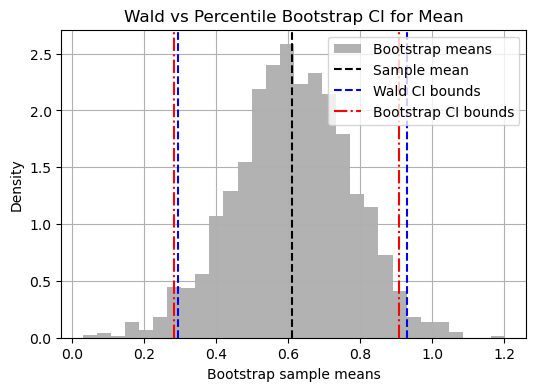

In [13]:
# Assume X, n, mu_hat, s_hat are from Q2(b)
# Example: reuse Q2(b) results here for continuity
np.random.seed(12345)
n = 200
true_mu = 0.5
true_s = 1.2
u = np.random.rand(n)
X = true_mu + true_s * np.log(u / (1 - u))  # logistic sample

# Let's assume we have estimated parameters from Q2(b)
mu_hat = np.median(X)
s_hat = np.std(X, ddof=1) * np.sqrt(3) / np.pi  # moment-based s

# -----------------------------
# (i) Wald CI for mean
# -----------------------------
alpha = 0.05
z = norm.ppf(1 - alpha / 2)
se_mean = (np.pi * s_hat) / np.sqrt(3 * n)
mean_hat = np.mean(X)
wald_ci = (mean_hat - z * se_mean, mean_hat + z * se_mean)

print("Wald CI for mean (95%):")
print(f"  Mean estimate = {mean_hat:.4f}")
print(f"  95% CI = [{wald_ci[0]:.4f}, {wald_ci[1]:.4f}]")

# -----------------------------
# (ii) Percentile Bootstrap CI
# -----------------------------
B = 2000
boot_means = np.zeros(B)
for b in range(B):
    Xb = np.random.choice(X, size=n, replace=True)
    boot_means[b] = np.mean(Xb)

boot_ci = (np.percentile(boot_means, 2.5),
           np.percentile(boot_means, 97.5))

print("\nPercentile Bootstrap CI for mean (95%):")
print(f"  95% CI = [{boot_ci[0]:.4f}, {boot_ci[1]:.4f}]")

# -----------------------------
# Comparison of CI widths
# -----------------------------
width_wald = wald_ci[1] - wald_ci[0]
width_boot = boot_ci[1] - boot_ci[0]

print("\nComparison:")
print(f"  Wald CI width      = {width_wald:.4f}")
print(f"  Bootstrap CI width  = {width_boot:.4f}")

# -----------------------------
# (Optional) Visualization
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(boot_means, bins=30, density=True, alpha=0.6, color='gray', label='Bootstrap means')
plt.axvline(mean_hat, color='k', linestyle='--', label='Sample mean')
plt.axvline(wald_ci[0], color='b', linestyle='--', label='Wald CI bounds')
plt.axvline(wald_ci[1], color='b', linestyle='--')
plt.axvline(boot_ci[0], color='r', linestyle='-.', label='Bootstrap CI bounds')
plt.axvline(boot_ci[1], color='r', linestyle='-.')
plt.xlabel("Bootstrap sample means")
plt.ylabel("Density")
plt.title("Wald vs Percentile Bootstrap CI for Mean")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
#Q5
# ----------------------------
# Utilities: fast KDE-backed logpdf factory and slice sampler
# ----------------------------
def fast_logpdf_factory(kde, grid_r):
    kde_pdf = kde(grid_r)                          # cache
    def fast_logpdf(r):
        # r can be scalar; ensure scalar handling
        rr = np.clip(np.asarray(r), grid_r[0], grid_r[-1])
        # linear interpolation via searchsorted
        idx = np.searchsorted(grid_r, rr) - 1
        idx = np.clip(idx, 0, len(grid_r)-2)
        x0 = grid_r[idx]; x1 = grid_r[idx+1]
        y0 = kde_pdf[idx]; y1 = kde_pdf[idx+1]
        w = (rr - x0) / (x1 - x0)
        y = y0 + w * (y1 - y0)
        # if input was scalar return scalar
        return np.log(np.maximum(y, np.finfo(float).tiny)) if np.isscalar(r) else np.log(np.maximum(y, np.finfo(float).tiny))
    return fast_logpdf

def slice1d_fast(logpdf, x0, w, max_steps, N, bounds):
    L, U = bounds
    samples = np.empty(N)
    x = np.clip(x0, L, U)
    for t in range(N):
        logy = logpdf(x) + np.log(np.random.rand())
        # initial interval
        u = np.random.rand() * w
        a = x - u
        b = x + (w - u)
        j = int(np.random.rand() * max_steps)
        k = (max_steps - 1) - j

        # step out (evaluating logpdf only when needed)
        fa = logpdf(a)
        while j > 0 and a > L and fa > logy:
            a = max(a - w, L)
            fa = logpdf(a)
            j -= 1

        fb = logpdf(b)
        while k > 0 and b < U and fb > logy:
            b = min(b + w, U)
            fb = logpdf(b)
            k -= 1

        # shrinkage
        while True:
            x_new = np.random.uniform(a, b)
            if logpdf(x_new) >= logy:
                x = x_new
                break
            if x_new < x:
                a = x_new
            else:
                b = x_new
        samples[t] = x
    return samples


In [17]:
# ----------------------------
# 5 (a) Bootstrap correlation matrices and vectorize unique correlations
# ----------------------------
np.random.seed(2025)

# Example data: multivariate normal (you may replace X with real data)
n = 200
d = 5
rho = 0.7
Sigma = rho ** np.abs(np.subtract.outer(np.arange(d), np.arange(d)))
X = np.random.multivariate_normal(np.zeros(d), Sigma, size=n)

# Bootstrap settings (tune B for speed vs accuracy)
B = 1500        # recommended 1000-2000 for real analysis; 1000 here for speed
inds = np.triu_indices(d, k=1)   # indices of unique off-diagonal correlations
p = len(inds[0])
Rvec = np.empty((B, p))

# vectorized-ish bootstrap: pregenerate sampling indices
# We'll loop over B to compute correlation matrices (d small so OK).
for b in range(B):
    idx = np.random.randint(0, n, size=n)   # rows resampled with replacement
    Xb = X[idx, :]
    Rb = np.corrcoef(Xb, rowvar=False)
    Rvec[b, :] = Rb[inds]

print(f"Bootstrap done: B={B}, d={d}, p={p}")


Bootstrap done: B=1500, d=5, p=10



Diagnostics for chosen r_{1,3}:
  r_boot mean=0.4615, sd=0.0485
  z_boot mean=0.5010, sd=0.0619


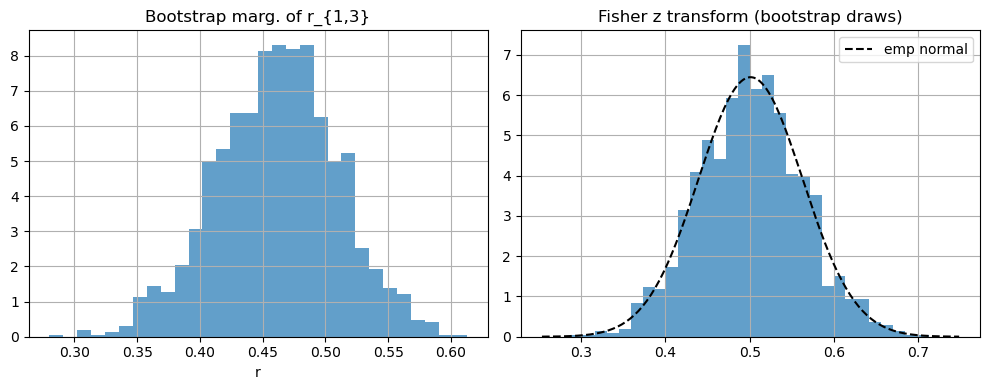

In [19]:
# ----------------------------
# (b) Which distribution approximates r*(b)?  -> Fisher z -> approx Normal
# Test: transform bootstrap correlations by Fisher z and check (approx) normality
# ----------------------------
# choose a pair to inspect (j,k) in 0-based indices
j, k = 0, 2   # corresponds to r_{1,3}
colmap = np.zeros((d,d), dtype=int)
colmap[inds] = np.arange(p)
col = colmap[j, k]
r_boot = Rvec[:, col]

# Fisher z transform
z_boot = 0.5 * np.log((1 + r_boot) / (1 - r_boot))

# Quick diagnostics: mean and sd vs normal
print("\nDiagnostics for chosen r_{%d,%d}:" % (j+1,k+1))
print("  r_boot mean=%.4f, sd=%.4f" % (np.mean(r_boot), np.std(r_boot, ddof=1)))
print("  z_boot mean=%.4f, sd=%.4f" % (np.mean(z_boot), np.std(z_boot, ddof=1)))

# Visual check
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(r_boot, bins=30, density=True, alpha=0.7)
plt.title(f'Bootstrap marg. of r_{{{j+1},{k+1}}}')
plt.xlabel('r'); plt.grid(True)

plt.subplot(1,2,2)
plt.hist(z_boot, bins=30, density=True, alpha=0.7)
# overlay normal with mean and var ~ 1/(n-3)
mu_z, sd_z = np.mean(z_boot), np.std(z_boot, ddof=1)
xs = np.linspace(mu_z-4*sd_z, mu_z+4*sd_z, 200)
plt.plot(xs, norm.pdf(xs, loc=mu_z, scale=sd_z), 'k--', label='emp normal')
plt.title('Fisher z transform (bootstrap draws)')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

The Fisher-z transform z = atanh(r) is approximately Normal for each marginal correlation; thus r's distribution is roughly the inverse-transform of a normal, especially for a large n.

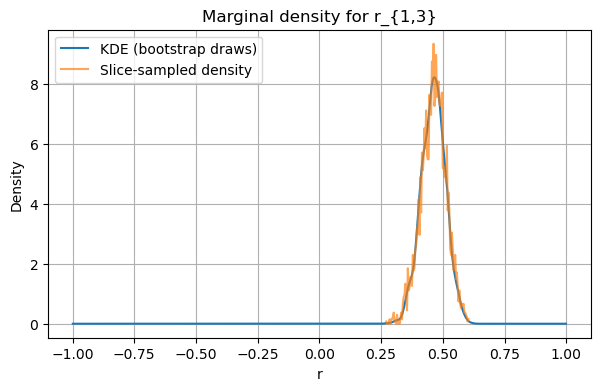

In [21]:
# ----------------------------
# (c) Slice sampling on marginal density for r_{j,k}
# Estimate KDE over (-1,1) and sample marginal with slice sampler
# ----------------------------
grid_r = np.linspace(-0.999, 0.999, 2000)
kde = gaussian_kde(r_boot)
kde_pdf = kde(grid_r)
pdf_fun = fast_logpdf_factory(kde, grid_r)   # returns logpdf

# Draw slice samples
Ns = 4000
burn = 1000
r0 = np.median(r_boot)
samples = slice1d_fast(pdf_fun, r0, w=0.05, max_steps=30, N=Ns+burn, bounds=(-0.999, 0.999))
r_slice = samples[burn:]

# show KDE vs slice-sampled density
plt.figure(figsize=(7,4))
# KDE
plt.plot(grid_r, kde_pdf, label='KDE (bootstrap draws)')
# histogram of slice samples (density)
hist_y, bin_edges = np.histogram(r_slice, bins=100, density=True)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.plot(centers, hist_y, label='Slice-sampled density', alpha=0.7)
plt.title(f'Marginal density for r_{{{j+1},{k+1}}}')
plt.xlabel('r'); plt.ylabel('Density'); plt.legend(); plt.grid(True)
plt.show()



CI comparison for r_{1,3} (n=200):
  Observed r (from original X)    = 0.4627
  Percentile bootstrap 95% CI    = [0.3622, 0.5567]
  Fisher-z analytic 95% CI (plug-in) = [0.3462, 0.5652]
  Widths: bootstrap=0.1945, fisher-z=0.2190


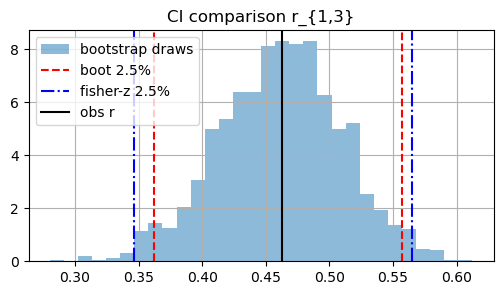

In [23]:
# ----------------------------
# (d) Compare percentile-bootstrap CI vs analytic Fisher-z CI
# ----------------------------
alpha = 0.05
# percentile bootstrap CI
ci_boot = np.percentile(r_boot, [100*alpha/2, 100*(1-alpha/2)])
# analytic Fisher-z CI using sample r (plug-in)
r_bar = np.mean(r_boot)   # or use sample correlation from original X
r_obs = np.corrcoef(X, rowvar=False)[j,k]
z_hat = 0.5 * np.log((1 + r_obs) / (1 - r_obs))
se_z = 1.0 / np.sqrt(n - 3)
z_ci = [z_hat - norm.ppf(1-alpha/2)*se_z, z_hat + norm.ppf(1-alpha/2)*se_z]
ci_fisher = [(np.exp(2*z)-1)/(np.exp(2*z)+1) for z in z_ci]

print("\nCI comparison for r_{%d,%d} (n=%d):" % (j+1,k+1,n))
print("  Observed r (from original X)    = %.4f" % r_obs)
print("  Percentile bootstrap 95%% CI    = [%.4f, %.4f]" % (ci_boot[0], ci_boot[1]))
print("  Fisher-z analytic 95%% CI (plug-in) = [%.4f, %.4f]" % (ci_fisher[0], ci_fisher[1]))

# compute widths
print("  Widths: bootstrap=%.4f, fisher-z=%.4f" % (ci_boot[1]-ci_boot[0], ci_fisher[1]-ci_fisher[0]))

# show on a plot
plt.figure(figsize=(6,3))
plt.hist(r_boot, bins=30, density=True, alpha=0.5, label='bootstrap draws')
plt.axvline(ci_boot[0], color='r', linestyle='--', label='boot 2.5%')
plt.axvline(ci_boot[1], color='r', linestyle='--')
plt.axvline(ci_fisher[0], color='b', linestyle='-.', label='fisher-z 2.5%')
plt.axvline(ci_fisher[1], color='b', linestyle='-.')
plt.axvline(r_obs, color='k', label='obs r')
plt.title(f'CI comparison r_{{{j+1},{k+1}}}')
plt.legend(); plt.grid(True); plt.show()



Interpretation 

Each off-diagonal correlation's bootstrap marginal is well-approximated
by transforming with Fisher z and is roughly Normal.

For this example the two CIs are similar in center but differ in width slightly.  The bootstrap percentile CI captures skewness and finite-sample asymmetry that the Fisher-z does not.

Geometry:
The space of the correlation matrices is constrained, additionally it is positive-definite. Uncertainty is not independent across unique elements. The bootstrap draws reflect those constraints.
Slice-sampling a single marginal ignores dependence structure but reveals marginal non-normality, although this looks relatively normal with mu .46 and a se of .9.
We know that full joint uncertainty lives on a curved manifold, and credible regions for R are curved subsets of that manifold. 
Additionally, per-element CIs only give marginal slices through that manifold.
When we need joint inference, we must account for the positive-definiteness constraint and covariance among elements. 
